# Assignment 1 — TensorFlow/Keras Setup and Data Preprocessing

**Aim:** Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing, normalization, train-test splitting, and data visualization on a sample dataset (Iris).

## 1. Install and Configure TensorFlow/Keras

In [1]:
# Install TensorFlow (already available in Colab, but this ensures the latest version)
!pip install tensorflow

In [2]:
# Verify TensorFlow installation
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. Import Required Libraries

In [3]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 3. Load the Iris Dataset

The Iris dataset contains 150 samples of iris flowers with 4 features each (sepal length, sepal width, petal length, petal width) and 3 target classes (Setosa, Versicolor, Virginica).

In [4]:
# Load the Iris dataset from sklearn
iris = load_iris()

X = iris.data     # Feature matrix (150 samples, 4 features)
y = iris.target   # Target labels (0, 1, 2)

In [5]:
# Create a DataFrame for easier exploration
df = pd.DataFrame(X, columns=iris.feature_names)
df["Target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Data Preprocessing

In [6]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
# Get statistical summary of the dataset
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
# Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

In [9]:
# Separate features and target variable
X = df.iloc[:, :-1]
y = df["Target"]

## 5. Data Normalization

StandardScaler standardizes features by removing the mean and scaling to unit variance. This helps the model converge faster during training.

In [10]:
# Normalize the features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 6. Train-Test Splitting

We split the dataset into 80% training and 20% testing data. The random_state ensures reproducibility.

In [11]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Verify the shapes of training and testing sets
print("Training set shape:", X_train.shape)
print("Testing set shape: ", X_test.shape)

Training set shape: (120, 4)
Testing set shape:  (30, 4)


## 7. Data Visualization

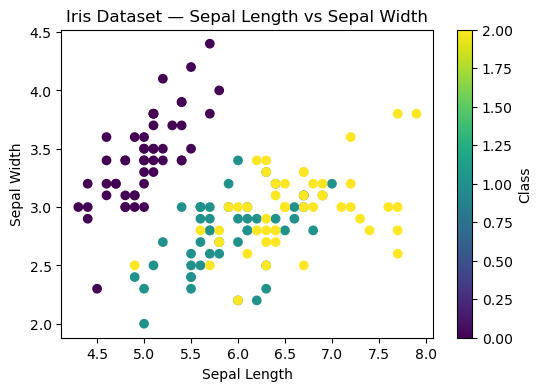

In [13]:
# Scatter plot of Sepal Length vs Sepal Width, colored by class
plt.figure(figsize=(6, 4))
scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=y, cmap='viridis')
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset — Sepal Length vs Sepal Width")
plt.colorbar(scatter, label="Class")
plt.show()

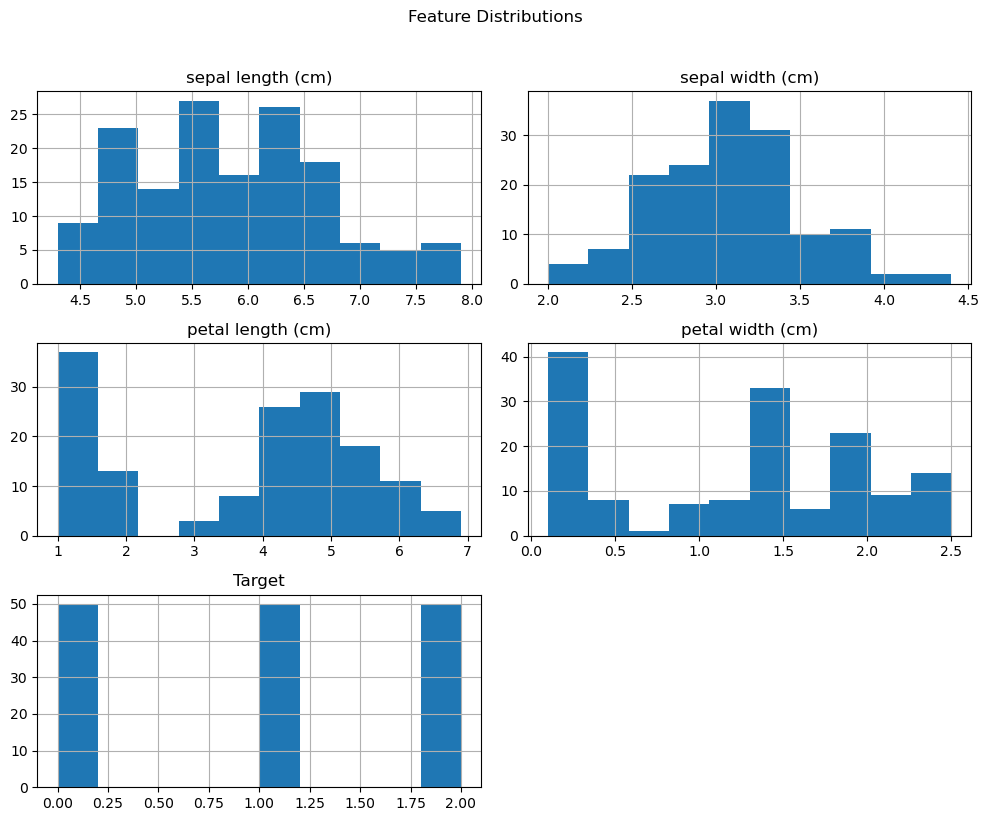

In [14]:
# Histogram of all features to see their distributions
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

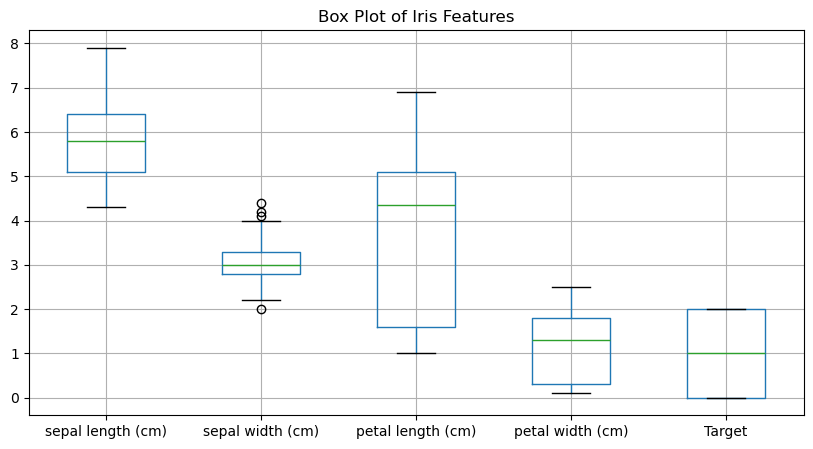

In [15]:
# Box plot to identify outliers in each feature
df.boxplot(figsize=(10, 5))
plt.title("Box Plot of Iris Features")
plt.show()

## 8. Simple Keras Model (Demo)

A basic neural network model to demonstrate that TensorFlow/Keras is configured correctly.

In [16]:
# Build a simple neural network to verify Keras is working
model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    keras.layers.Dense(3, activation='softmax')
])

model.summary()

c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

## Conclusion

In this assignment, we successfully:
1. Installed and configured TensorFlow/Keras in Google Colab.
2. Loaded the Iris dataset and explored its structure.
3. Performed data preprocessing (checking for missing values, data types).
4. Normalized the features using StandardScaler.
5. Split the data into training (80%) and testing (20%) sets.
6. Visualized the data using scatter plots, histograms, and box plots.
7. Built a simple Keras model to verify the setup.